In [6]:
# ================================
# PROYECTO FINAL ML - MARIA ANGULO
# DATASET SELECCIONADO: WINE
# ================================
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine

# Cargar dataset
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

# Exploración inicial
print("Shape:", X.shape)
print("Clases:", np.unique(y))
print("Tipos de datos:\n", X.dtypes)
print("Valores faltantes:\n", X.isnull().sum())
for col in X.columns:
    print(f"\nColumna: {col}")
    print("Valores únicos:", X[col].unique()[:10], "...") 
    print("Tipo de dato:", X[col].dtype)
    # Verificar si mezcla texto/números
    if pd.api.types.is_numeric_dtype(X[col]):
        print(f"{col}: Solo números")
    else:
        print(f"{col}: Mezcla de texto/números")
    # verificar si hay valores 0
    zeros = (X[col] == 0).sum()
    print(f"{col}: {zeros} valores 0")
# Dataset 100% numerico sin faltantes, unicamente se realizara escala/normalizacion

Shape: (178, 13)
Clases: [0 1 2]
Tipos de datos:
 alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object
Valores faltantes:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Split del dataset en train y test se fija random_state 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Se realizara normalizacion/escala solo para el modelo MLP. Para XGBoost y Random Forest no es necesario.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# ================================
# EXPERIMENTOS POR MODELO
# ================================
# Hiperparámetros a variar, se guardan las combinaciones en una lista de diccionarios

# ================================
# RANDOM FOREST
# ================================
from sklearn.ensemble import RandomForestClassifier
rf_params = [
    {"n_estimators":100, "max_depth":None},
    {"n_estimators":200, "max_depth":10},
    {"n_estimators":300, "min_samples_leaf":3},
    {"n_estimators":150, "max_features":"sqrt"},
    {"n_estimators":250, "criterion":"entropy"}
]

rf_models = []
for params in rf_params:
    model = RandomForestClassifier(random_state=42, **params)
    model.fit(X_train, y_train)
    rf_models.append((params, model))

In [9]:
# ================================
# xGBoost
# ================================
from xgboost import XGBClassifier

xgb_params = [
    {"n_estimators":100, "max_depth":3, "learning_rate":0.1},
    {"n_estimators":200, "max_depth":5, "learning_rate":0.05},
    {"n_estimators":300, "subsample":0.8, "colsample_bytree":0.8},
    {"n_estimators":150, "reg_lambda":2.0},
    {"n_estimators":250, "max_depth":4, "learning_rate":0.2}
]

xgb_models = []
for params in xgb_params:
    model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="mlogloss", **params)
    model.fit(X_train, y_train)
    xgb_models.append((params, model))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:07:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:07:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:07:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:07:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [10]:
# ================================
# Red Neuronal MLP
# ================================
# se utilizan las features escaladas para mejorar rendimiento
from sklearn.neural_network import MLPClassifier

mlp_params = [
    {"hidden_layer_sizes":(5,), "activation":"relu", "max_iter":500},
    {"hidden_layer_sizes":(10,), "activation":"tanh", "max_iter":500},
    {"hidden_layer_sizes":(20,30), "activation":"relu", "max_iter":500},
    {"hidden_layer_sizes":(50), "activation":"relu", "learning_rate_init":0.01},
    {"hidden_layer_sizes":(100,), "activation":"relu", "alpha":0.001}
]

mlp_models = []
for params in mlp_params:
    model = MLPClassifier(random_state=42, **params)
    model.fit(X_train_scaled, y_train)
    mlp_models.append((params, model))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [11]:
# Evaluacion de modelos y resultados obtenidos
import os
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

#if os.path.exists("experimentos.csv"):
#    os.remove("experimentos.csv")

BITACORA = "experimentos.csv"

def metricas(y_true, y_pred, sufijo):
    return {
        f"precision_{sufijo}": precision_score(y_true, y_pred, average="macro"),
        f"recall_{sufijo}":    recall_score(y_true, y_pred, average="macro"),
        f"f1_{sufijo}":        f1_score(y_true, y_pred, average="macro"),
        f"accuracy_{sufijo}":  accuracy_score(y_true, y_pred),
    }

def diagnostico(f1_train, f1_test):
    diff = f1_train - f1_test
    if f1_train < 0.7 and f1_test < 0.7:
        return "Underfitting - f1 < 0.7"
    elif diff >= 0.03:
        return "Overfitting - (f1_train - f1_test) >= 0.05"
    else:
        return "Buen ajuste - (f1_train - f1_test) < 0.05"

def registrar(exp_id, modelo, hiperparams, arquitectura, model, Xtr, ytr, Xte, yte):
    fila = {
        "experimento_id": exp_id,
        "modelo": modelo,
        "hiperparametros": str(hiperparams),
        "arquitectura": arquitectura if arquitectura else "No aplica"
    }
    # métricas en TRAIN
    y_pred_train = model.predict(Xtr)
    fila.update(metricas(ytr, y_pred_train, "train"))
    # métricas en TEST
    y_pred_test = model.predict(Xte)
    fila.update(metricas(yte, y_pred_test, "test"))
    # diagnóstico
    fila["diagnostico"] = diagnostico(fila["f1_train"], fila["f1_test"])
    # guardar en CSV 
    pd.DataFrame([fila]).to_csv(
        BITACORA, mode="a", header=not os.path.exists(BITACORA), index=False
    )

# Random Forest 
for i, (params, model) in enumerate(rf_models, start=1):
    registrar(f"RF_{i:02d}", "RandomForest", params, "", model, X_train, y_train, X_test, y_test)

# XGBoost 
for i, (params, model) in enumerate(xgb_models, start=1):
    registrar(f"XGB_{i:02d}", "XGBoost", params, "", model, X_train, y_train, X_test, y_test)

# MLP (con escalado)
for i, (params, model) in enumerate(mlp_models, start=1):
    registrar(f"MLP_{i:02d}", "MLP", params, str(params.get("hidden_layer_sizes","")), 
              model, X_train_scaled, y_train, X_test_scaled, y_test)


tabla = pd.read_csv(BITACORA)
print(tabla)



   experimento_id        modelo  \
0           RF_01  RandomForest   
1           RF_02  RandomForest   
2           RF_03  RandomForest   
3           RF_04  RandomForest   
4           RF_05  RandomForest   
5          XGB_01       XGBoost   
6          XGB_02       XGBoost   
7          XGB_03       XGBoost   
8          XGB_04       XGBoost   
9          XGB_05       XGBoost   
10         MLP_01           MLP   
11         MLP_02           MLP   
12         MLP_03           MLP   
13         MLP_04           MLP   
14         MLP_05           MLP   
15          RF_01  RandomForest   
16          RF_02  RandomForest   
17          RF_03  RandomForest   
18          RF_04  RandomForest   
19          RF_05  RandomForest   
20         XGB_01       XGBoost   
21         XGB_02       XGBoost   
22         XGB_03       XGBoost   
23         XGB_04       XGBoost   
24         XGB_05       XGBoost   
25         MLP_01           MLP   
26         MLP_02           MLP   
27         MLP_03   

In [12]:
#Seleccion de experimentos mejores por familia de modelos
# tomando en cuenta que el dataset es sencillo varios experimentos tienen un mismo desempeño

bitacora = pd.read_csv("experimentos.csv")

def seleccionar_mejor(bitacora, modelo):
    subset = bitacora[bitacora["modelo"] == modelo].copy()
    # Ordenar por f1_test descendente, luego por experimento_id para romper empates
    subset = subset.sort_values(by=["f1_test", "experimento_id"], ascending=[False, True])
    return subset.iloc[0]

best_rf  = seleccionar_mejor(bitacora, "RandomForest")
best_xgb = seleccionar_mejor(bitacora, "XGBoost")
best_mlp = seleccionar_mejor(bitacora, "MLP")
print("Mejor RF:\n", best_rf, "\n")
print("Mejor XGB:\n", best_xgb, "\n")
print("Mejor MLP:\n", best_mlp, "\n")


Mejor RF:
 experimento_id                                         RF_01
modelo                                          RandomForest
hiperparametros     {'n_estimators': 100, 'max_depth': None}
arquitectura                                       No aplica
precision_train                                          1.0
recall_train                                             1.0
f1_train                                                 1.0
accuracy_train                                           1.0
precision_test                                           1.0
recall_test                                              1.0
f1_test                                                  1.0
accuracy_test                                            1.0
diagnostico        Buen ajuste - (f1_train - f1_test) < 0.05
Name: 0, dtype: object 

Mejor XGB:
 experimento_id                                                XGB_01
modelo                                                       XGBoost
hiperparametros    {'

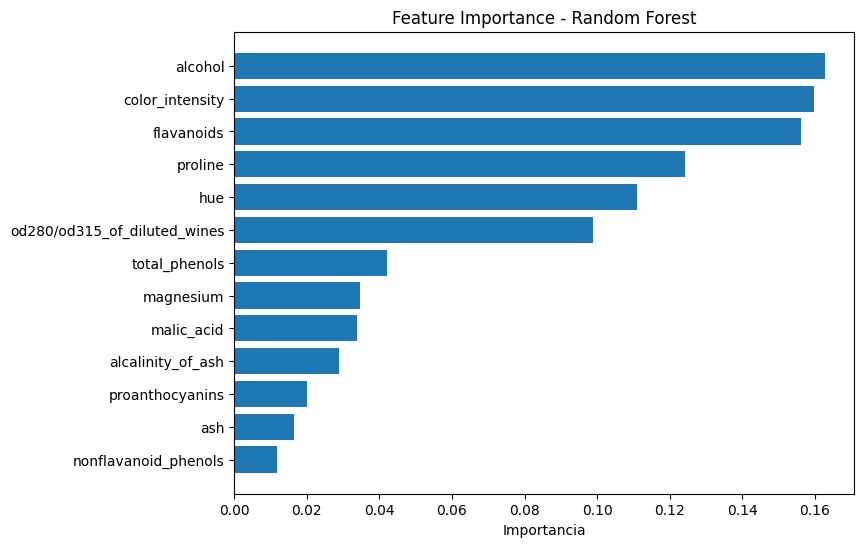

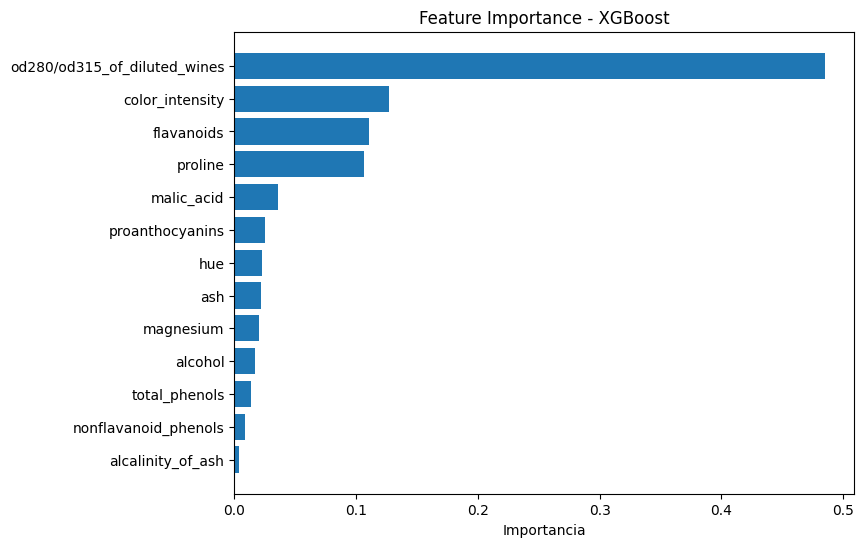

In [13]:
# Feature importance para los mejores modelos de RF y XGB
import matplotlib.pyplot as plt
import numpy as np

# Selección de la mejor fila 
best_rf_row = seleccionar_mejor(tabla, "RandomForest")
best_xgb_row = seleccionar_mejor(tabla, "XGBoost")

# Buscar el modelo entrenado correspondiente
best_rf = None
for params, model in rf_models:
    if str(params) == best_rf_row["hiperparametros"]:
        best_rf = model
        break

best_xgb = None
for params, model in xgb_models:
    if str(params) == best_xgb_row["hiperparametros"]:
        best_xgb = model
        break

# Random forest
# Random Forest
rf_importances = best_rf.feature_importances_
rf_features = X.columns
rf_sorted_idx = np.argsort(rf_importances)[::-1]

plt.figure(figsize=(8,6))
plt.barh(range(len(rf_importances)), rf_importances[rf_sorted_idx])
plt.yticks(range(len(rf_importances)), rf_features[rf_sorted_idx])
plt.gca().invert_yaxis()  # la más importante arriba
plt.xlabel("Importancia")
plt.title("Feature Importance - Random Forest")
plt.show()

# XGBoost
xgb_importances = best_xgb.feature_importances_
xgb_features = X.columns
xgb_sorted_idx = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(8,6))
plt.barh(range(len(xgb_importances)), xgb_importances[xgb_sorted_idx])
plt.yticks(range(len(xgb_importances)), xgb_features[xgb_sorted_idx])
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.title("Feature Importance - XGBoost")
plt.show()



In [14]:
#Ensamble de los mejores modelos de cada familia
import numpy as np
from scipy.stats import mode
from sklearn.metrics import f1_score

best_rf_row  = seleccionar_mejor(tabla, "RandomForest")
best_xgb_row = seleccionar_mejor(tabla, "XGBoost")
best_mlp_row = seleccionar_mejor(tabla, "MLP")

# Buscar el modelo entrenado correspondiente
best_rf = None
for params, model in rf_models:
    if str(params) == best_rf_row["hiperparametros"]:
        best_rf = model
        break

best_xgb = None
for params, model in xgb_models:
    if str(params) == best_xgb_row["hiperparametros"]:
        best_xgb = model
        break

best_mlp = None
for params, model in mlp_models:
    if str(params) == best_mlp_row["hiperparametros"]:
        best_mlp = model
        break
    
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np  = X_test.values

modelos = [best_rf, best_xgb, best_mlp]
preds = []

for m in modelos:
    # Bootstrap
    idx = np.random.choice(len(X_train_np), size=len(X_train_np), replace=True)
    X_boot, y_boot = X_train_np[idx], y_train_np[idx]
    m.fit(X_boot, y_boot)
    preds.append(m.predict(X_test_np))

preds = np.vstack(preds) 

# Voto mayoritario con regla de desempate
y_ensamble = []
for j in range(preds.shape[1]):
    votos = preds[:, j]
    moda = mode(votos, keepdims=True)  
    if moda.count[0] > 1:
        y_ensamble.append(moda.mode[0])
    else:
        # Empate: cada modelo vota distinto
        f1_scores = [f1_score(y_test, preds[i], average="macro") for i in range(3)]
        mejor_idx = np.argmax(f1_scores)
        y_ensamble.append(preds[mejor_idx, j])

y_ensamble = np.array(y_ensamble)

# Evaluar desempeño del ensamble
f1_ensamble = f1_score(y_test, y_ensamble, average="macro")
print("F1 del ensamble:", f1_ensamble)


F1 del ensamble: 0.9827242524916944


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:08:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [15]:
import pandas as pd


best_rf_row  = seleccionar_mejor(tabla, "RandomForest")
best_xgb_row = seleccionar_mejor(tabla, "XGBoost")
best_mlp_row = seleccionar_mejor(tabla, "MLP")

# Construir tabla comparativa
comparativa = pd.DataFrame([
    {
        "Modelo": best_rf_row["modelo"],
        "F1_train": best_rf_row["f1_train"],
        "F1_test": best_rf_row["f1_test"],
        "Diferencia": best_rf_row["f1_train"] - best_rf_row["f1_test"],
        "Diagnóstico": best_rf_row["diagnostico"]
    },
    {
        "Modelo": best_xgb_row["modelo"],
        "F1_train": best_xgb_row["f1_train"],
        "F1_test": best_xgb_row["f1_test"],
        "Diferencia": best_xgb_row["f1_train"] - best_xgb_row["f1_test"],
        "Diagnóstico": best_xgb_row["diagnostico"]
    },
    {
        "Modelo": best_mlp_row["modelo"],
        "F1_train": best_mlp_row["f1_train"],
        "F1_test": best_mlp_row["f1_test"],
        "Diferencia": best_mlp_row["f1_train"] - best_mlp_row["f1_test"],
        "Diagnóstico": best_mlp_row["diagnostico"]
    },
    {
        "Modelo": "Ensamble",
        "F1_train": None,  # no aplica porque se entrena con bootstrap
        "F1_test": f1_ensamble,
        "Diferencia": None,
        "Diagnóstico": "Buen ajuste (mayoría estable)"
    }
])

print(comparativa)


         Modelo  F1_train   F1_test  Diferencia  \
0  RandomForest       1.0  1.000000         0.0   
1       XGBoost       1.0  1.000000         0.0   
2           MLP       1.0  1.000000         0.0   
3      Ensamble       NaN  0.982724         NaN   

                                 Diagnóstico  
0  Buen ajuste - (f1_train - f1_test) < 0.05  
1  Buen ajuste - (f1_train - f1_test) < 0.05  
2  Buen ajuste - (f1_train - f1_test) < 0.05  
3              Buen ajuste (mayoría estable)  


In [16]:
import xgboost as xgb
from google.colab import files
files.download("/content/experimentos.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>